# 09 - Hand-by-hand odd/even phase map

This notebook uses the saved scanner `.mat` file from `example.ipynb` and estimates the even/odd phase map directly with torch. It does not call `spenpy.recon.phase.even_odd_phase_fit`.

The phase correction steps are:

1. Split the ROFFT data into odd and even PE lines.
2. Reconstruct odd/even partial images with their own half-size SPEN matrices.
3. Estimate the coil-combined complex phase difference `even * conj(odd)`.
4. Build a simple foreground mask and weights.
5. Fit a smooth quadratic phase model using a circular phase loss.
6. Smooth the remaining wrapped residual and correct the even lines.


In [ ]:
import sys
from pathlib import Path

import scipy.io
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path("/home/data1/musong/workspace/python/spen_recons")
sys.path.insert(0, str(ROOT / "spenpy"))

from spenpy.core import calcInvA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
mat_path = ROOT / "data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat"
mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

rofft_np = mat["spen_original_signal_rofft"]
if rofft_np.ndim == 3:
    rofft_np = rofft_np[:, :, None, :]

rofft = torch.as_tensor(rofft_np, dtype=torch.complex64, device=device)
spen_original = torch.as_tensor(mat["spen_original"], device=device)
params = mat["calc_inva_params"]

print("ROFFT shape [PE, RO, image, coil]:", tuple(rofft.shape))
print("spen_original shape:", tuple(spen_original.shape))


ROFFT shape [PE, RO, image, coil]: (96, 96, 1, 4)
spen_original shape: (96, 96)


In [3]:
def build_inva(args):
    """Build one InvA matrix from the arguments saved in the scanner mat."""
    args = torch.as_tensor(args, dtype=torch.float64).flatten()
    inv_a, _ = calcInvA(
        args[0],
        args[1],
        int(args[2].item()),
        args[3],
        int(args[4].item()),
        args[5],
        args[6],
    )
    return inv_a.to(device=device, dtype=torch.complex64)


def apply_pe_matrix(matrix, signal):
    """Apply a PE reconstruction matrix to a signal shaped [PE, ...]."""
    return torch.einsum("ij,j...->i...", matrix, signal)


def rss_image_from_rofft(signal, inv_a):
    """Simple root-sum-of-squares image for quick visualization."""
    sr = apply_pe_matrix(inv_a, signal)
    coil_images = sr[:, :, 0, :]
    return torch.sqrt(torch.sum(torch.abs(coil_images) ** 2, dim=-1))


def orient_for_display(image):
    return torch.flip(image, dims=(0, 1))


def display_abs(image, percentile=99.5):
    image = torch.abs(image).to(torch.float32)
    positive = image[image > 0]
    if positive.numel() == 0:
        scale = torch.tensor(1.0, device=image.device)
    else:
        scale = torch.quantile(positive, percentile / 100.0).clamp_min(1e-8)
    return torch.clamp(image / scale, 0.0, 1.0)


def show(axis, image, title, cmap="gray", vmin=None, vmax=None):
    data = image.detach().cpu() if isinstance(image, torch.Tensor) else image
    im = axis.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set_title(title)
    axis.axis("off")
    plt.colorbar(im, ax=axis, fraction=0.046, pad=0.04)


In [4]:
inv_a = build_inva(params.full_args)
odd_inv = build_inva(params.odd_args)
even_inv = build_inva(params.even_args)

recon_before = rss_image_from_rofft(rofft, inv_a)

print("full InvA:", tuple(inv_a.shape))
print("odd InvA:", tuple(odd_inv.shape))
print("even InvA:", tuple(even_inv.shape))


full InvA: (96, 96)
odd InvA: (48, 48)
even InvA: (48, 48)


In [5]:
# Odd and even are reconstructed separately because their SPEN trajectories are shifted.
odd_sr = apply_pe_matrix(odd_inv, rofft[0::2])
even_sr = apply_pe_matrix(even_inv, rofft[1::2])

odd_img = odd_sr[:, :, 0, :]
even_img = even_sr[:, :, 0, :]

# Coil-combined phase difference. The phase of this complex image is the even-vs-odd phase error.
phase_cross = torch.sum(even_img * torch.conj(odd_img), dim=-1)
raw_phase = torch.angle(phase_cross)

odd_mag = torch.sqrt(torch.sum(torch.abs(odd_img) ** 2, dim=-1))
even_mag = torch.sqrt(torch.sum(torch.abs(even_img) ** 2, dim=-1))
min_mag = torch.minimum(odd_mag, even_mag)

print("odd/even image shape:", tuple(raw_phase.shape))


odd/even image shape: (48, 96)


In [6]:
# A small foreground mask keeps the fit away from background and low-SNR pixels.
mag_diff_std = torch.std(even_mag - odd_mag)
mag_mask = (odd_mag > 2.0 * mag_diff_std) & (even_mag > 2.0 * mag_diff_std)

strength = torch.abs(phase_cross)
if torch.any(mag_mask):
    strength_cutoff = torch.quantile(strength[mag_mask], 0.20)
else:
    strength_cutoff = torch.tensor(0.0, device=device)

mask = mag_mask & (strength >= strength_cutoff) & torch.isfinite(raw_phase)

# Weight stronger pixels more, but keep the weights numerically small.
weights = mask.to(torch.float32) * min_mag.to(torch.float32)
weights = weights / weights.max().clamp_min(1e-8)

print("mask fraction:", float(mask.to(torch.float32).mean().detach().cpu()))


mask fraction: 0.2799479067325592


In [7]:
def wrap_to_pi(x):
    return torch.atan2(torch.sin(x), torch.cos(x))


def circular_mean(angle, weight):
    c = torch.sum(weight * torch.cos(angle))
    s = torch.sum(weight * torch.sin(angle))
    return torch.atan2(s, c)


def quadratic_terms(height, width, device, dtype):
    y = torch.linspace(-1.0, 1.0, height, device=device, dtype=dtype)
    x = torch.linspace(-1.0, 1.0, width, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    terms = torch.stack(
        [
            torch.ones_like(xx),
            xx,
            yy,
            xx * xx,
            xx * yy,
            yy * yy,
        ],
        dim=-1,
    )
    return terms


def fit_circular_quadratic_phase(raw_phase, weights, max_iter=200):
    """Fit phase = c0 + c1*x + c2*y + c3*x^2 + c4*x*y + c5*y^2.

    The loss is circular, so no explicit 2D phase unwrap is needed:
        loss = -mean(weight * cos(raw_phase - model_phase))
    """
    height, width = raw_phase.shape
    terms = quadratic_terms(height, width, raw_phase.device, raw_phase.dtype)
    design = terms.reshape(-1, 6)
    target = raw_phase.reshape(-1)
    weight = weights.reshape(-1)
    keep = torch.isfinite(target) & torch.isfinite(weight) & (weight > 0)

    if torch.count_nonzero(keep) < 6:
        raise RuntimeError("Not enough valid pixels for the 6-parameter phase fit.")

    design_fit = design[keep]
    target_fit = target[keep]
    weight_fit = weight[keep]

    coeffs = torch.zeros(6, dtype=raw_phase.dtype, device=raw_phase.device, requires_grad=True)
    coeffs.data[0] = circular_mean(target_fit, weight_fit)

    optimizer = torch.optim.LBFGS(
        [coeffs],
        lr=0.8,
        max_iter=max_iter,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        model = design_fit @ coeffs
        loss = -torch.sum(weight_fit * torch.cos(target_fit - model)) / torch.sum(weight_fit)
        loss.backward()
        return loss

    optimizer.step(closure)

    with torch.no_grad():
        phase_poly = (design @ coeffs).reshape(height, width)
    return coeffs.detach(), phase_poly.detach()


def weighted_box_smooth(values, weights, kernel_size=11):
    pad = kernel_size // 2
    kernel = torch.ones((1, 1, kernel_size, kernel_size), dtype=values.dtype, device=values.device)
    numerator = F.conv2d((values * weights).unsqueeze(0).unsqueeze(0), kernel, padding=pad)
    denominator = F.conv2d(weights.unsqueeze(0).unsqueeze(0), kernel, padding=pad)
    return (numerator / denominator.clamp_min(1e-6)).squeeze(0).squeeze(0)


In [8]:
fit_phase = raw_phase.to(torch.float32)
fit_weights = weights.to(torch.float32)

coeffs, phase_poly = fit_circular_quadratic_phase(fit_phase, fit_weights)

# The polynomial gets the large smooth trend. The local residual is wrapped and smoothed.
residual = wrap_to_pi(fit_phase - phase_poly)
residual_smooth = weighted_box_smooth(residual, mask.to(torch.float32), kernel_size=11)
phase_map = phase_poly + residual_smooth

weighted_residual = torch.sum(torch.abs(wrap_to_pi(fit_phase - phase_map)) * fit_weights) / torch.sum(fit_weights)

print("quadratic coeffs on normalized x/y:")
print(coeffs.detach().cpu())
print("phase map range:", float(phase_map.min().detach().cpu()), float(phase_map.max().detach().cpu()))
print("weighted residual abs phase:", float(weighted_residual.detach().cpu()))


quadratic coeffs on normalized x/y:
tensor([-1.0659,  0.2257,  0.2300, -0.0323, -0.4783, -0.3780])
phase map range: -4.320405960083008 -0.035768985748291016
weighted residual abs phase: 0.14469002187252045


In [9]:
corrected_rofft = rofft.clone()
corrected_rofft[1::2] *= torch.exp(-1j * phase_map[:, :, None, None])

recon_after = rss_image_from_rofft(corrected_rofft, inv_a)
recon_diff = torch.abs(display_abs(recon_after) - display_abs(recon_before))

print("corrected ROFFT shape:", tuple(corrected_rofft.shape))


corrected ROFFT shape: (96, 96, 1, 4)


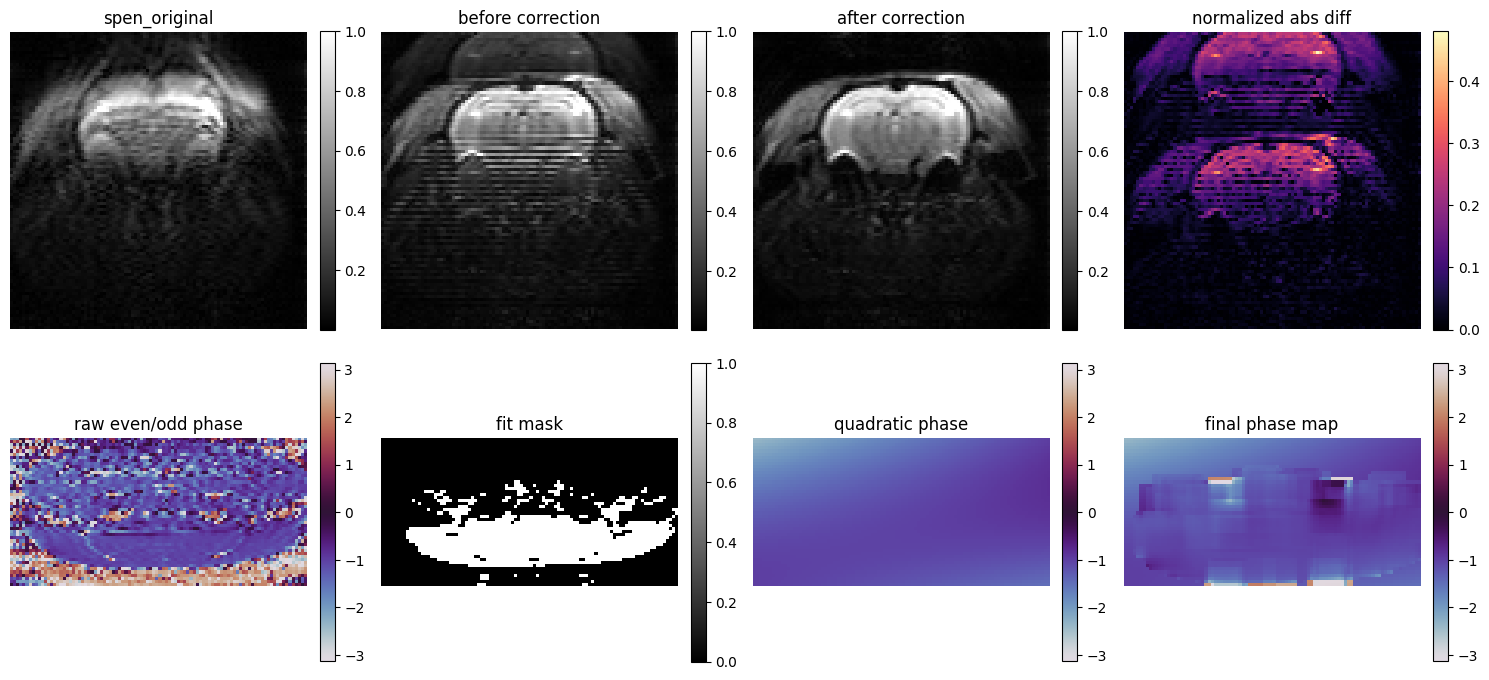

In [10]:
fig, ax = plt.subplots(2, 4, figsize=(15, 7))

show(ax[0, 0], display_abs(spen_original), "spen_original")
show(ax[0, 1], display_abs(orient_for_display(recon_before)), "before correction")
show(ax[0, 2], display_abs(orient_for_display(recon_after)), "after correction")
show(ax[0, 3], orient_for_display(recon_diff), "normalized abs diff", "magma")

show(ax[1, 0], raw_phase, "raw even/odd phase", "twilight", -torch.pi, torch.pi)
show(ax[1, 1], mask.to(torch.float32), "fit mask", "gray", 0.0, 1.0)
show(ax[1, 2], wrap_to_pi(phase_poly), "quadratic phase", "twilight", -torch.pi, torch.pi)
show(ax[1, 3], wrap_to_pi(phase_map), "final phase map", "twilight", -torch.pi, torch.pi)

plt.tight_layout()
